In [1]:
import sys
print(sys.executable)
# Must show: D:\New folder\envs\surprise_env\python.exe ✅

import sklearn, xgboost, shap
print("✅ sklearn :", sklearn.__version__)
print("✅ xgboost :", xgboost.__version__)
print("✅ shap    :", shap.__version__)

D:\New folder\envs\surprise_env\python.exe
✅ sklearn : 1.7.2
✅ xgboost : 3.2.0
✅ shap    : 0.49.1


In [2]:
# Paste this as Cell 1 in Notebook 04 to confirm all imports work

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings("ignore")

print("✅ pandas     :", pd.__version__)
print("✅ numpy      :", np.__version__)
print("✅ sklearn    :", __import__('sklearn').__version__)
print("✅ xgboost    :", __import__('xgboost').__version__)
print("✅ shap       :", shap.__version__)
print("\n🎉 All libraries ready — proceed with Cell 2!")

✅ pandas     : 2.3.3
✅ numpy      : 1.26.4
✅ sklearn    : 1.7.2
✅ xgboost    : 3.2.0
✅ shap       : 0.49.1

🎉 All libraries ready — proceed with Cell 2!


In [3]:
master_df    = pd.read_csv("data/sfe_master_dataset.csv", parse_dates=["datum"])
territory_agg = pd.read_csv("data/sfe_territory_agg.csv")

print(f"Master   : {master_df.shape}")
print(f"Territory: {territory_agg.shape}")

Master   : (14000, 14)
Territory: (200, 12)


#Elbow + silhouette to find best K

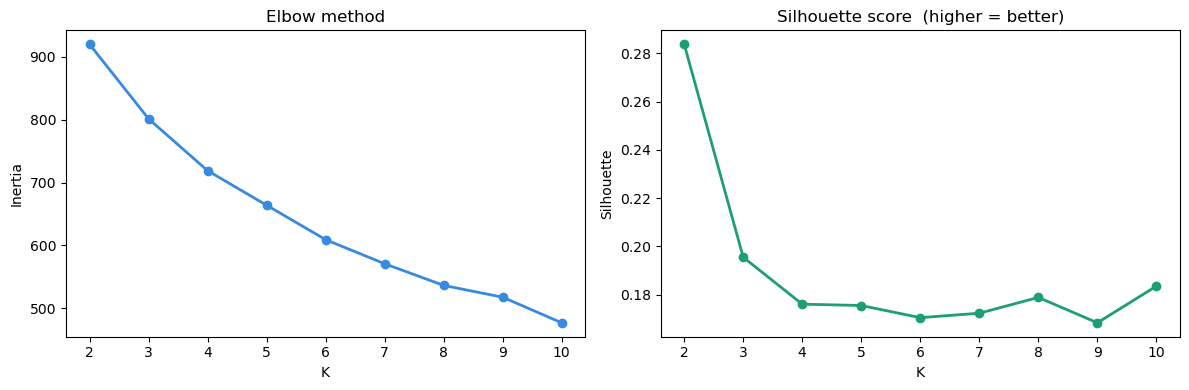

Best K by silhouette: 2


In [4]:
CLUSTER_FEATURES = ["avg_calls","avg_samples","avg_digital",
                    "avg_competitor","avg_market_access",
                    "rx_per_call","hcp_tier"]

X_clust = territory_agg[CLUSTER_FEATURES].copy()
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias,   "o-", color="#378ADD", linewidth=2)
axes[0].set_title("Elbow method")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, sil_scores, "o-", color="#1D9E75", linewidth=2)
axes[1].set_title("Silhouette score  (higher = better)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.savefig("outputs/06_elbow_silhouette.png", dpi=150)
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Best K by silhouette: {best_k}")

In [6]:
# Fit final K-Means & label segments

In [7]:
BEST_K = 4   # adjust if your silhouette says otherwise

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
territory_agg["cluster"] = km_final.fit_predict(X_scaled)

# Summarise each cluster
cluster_profile = territory_agg.groupby("cluster")[
    CLUSTER_FEATURES + ["avg_rx"]].mean().round(2)
print("Cluster profiles:")
print(cluster_profile.to_string())

# Assign business labels based on avg_rx and rx_per_call
rx_rank  = cluster_profile["avg_rx"].rank()
roi_rank = cluster_profile["rx_per_call"].rank()

segment_map = {}
for c in range(BEST_K):
    if rx_rank[c] == BEST_K and roi_rank[c] >= BEST_K - 1:
        segment_map[c] = "Star territories"
    elif rx_rank[c] == 1:
        segment_map[c] = "Low potential"
    elif roi_rank[c] == 1:
        segment_map[c] = "High effort, low ROI"
    else:
        segment_map[c] = "Growth opportunity"

territory_agg["segment"] = territory_agg["cluster"].map(segment_map)
print("\nSegment distribution:")
print(territory_agg["segment"].value_counts())

Cluster profiles:
         avg_calls  avg_samples  avg_digital  avg_competitor  avg_market_access  rx_per_call  hcp_tier   avg_rx
cluster                                                                                                        
0             9.71        17.01         4.90            0.35               6.17       109.83      2.07  1068.59
1             9.07        15.79         4.55            0.39               5.99       142.19      2.43  1289.81
2            10.78        18.95         5.51            0.37               5.99       141.19      1.39  1520.83
3             8.14        14.11         4.08            0.36               5.96       183.06      2.74  1487.28

Segment distribution:
segment
Growth opportunity    154
Low potential          46
Name: count, dtype: int64


In [8]:
# Cluster visualisation

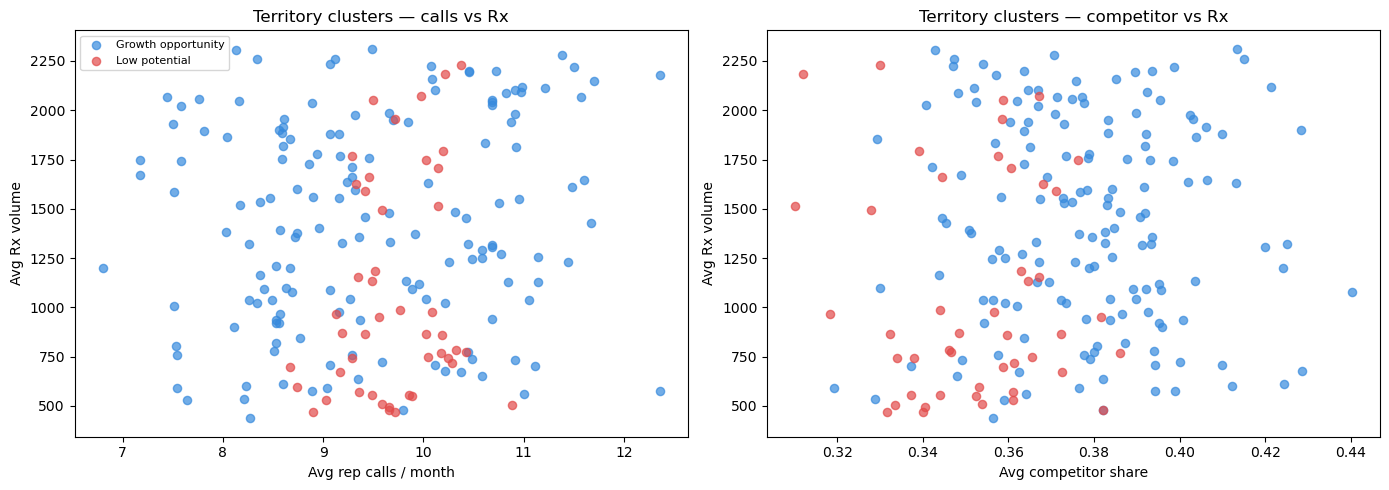

In [9]:
SEG_COLORS = {
    "Star territories"    : "#1D9E75",
    "Growth opportunity"  : "#378ADD",
    "High effort, low ROI": "#BA7517",
    "Low potential"       : "#E24B4A"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: calls vs Rx volume
for seg, grp in territory_agg.groupby("segment"):
    axes[0].scatter(grp["avg_calls"], grp["avg_rx"],
                    label=seg, alpha=0.7, s=35, color=SEG_COLORS.get(seg, "grey"))
axes[0].set_xlabel("Avg rep calls / month")
axes[0].set_ylabel("Avg Rx volume")
axes[0].set_title("Territory clusters — calls vs Rx")
axes[0].legend(fontsize=8)

# Plot 2: competitor share vs Rx
for seg, grp in territory_agg.groupby("segment"):
    axes[1].scatter(grp["avg_competitor"], grp["avg_rx"],
                    label=seg, alpha=0.7, s=35, color=SEG_COLORS.get(seg, "grey"))
axes[1].set_xlabel("Avg competitor share")
axes[1].set_ylabel("Avg Rx volume")
axes[1].set_title("Territory clusters — competitor vs Rx")

plt.tight_layout()
plt.savefig("outputs/07_clusters.png", dpi=150)
plt.show()

In [10]:
#XGBoost model (monthly level)

In [11]:
FEATURE_COLS = ["calls","samples_dropped","digital_touches",
                "competitor_share","market_access",
                "seasonality_idx","hcp_tier","rep_tenure",
                "month","year"]
TARGET = "rx_volume"

X = master_df[FEATURE_COLS]
y = master_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- Baseline ---
lr = LinearRegression().fit(X_train, y_train)
lr_r2   = r2_score(y_test, lr.predict(X_test))
lr_rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))
print(f"Baseline Linear Regression  →  R²: {lr_r2:.4f}  RMSE: {lr_rmse:.2f}")

# --- XGBoost ---
xgb = XGBRegressor(
    n_estimators   = 400,
    learning_rate  = 0.04,
    max_depth      = 5,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    random_state   = 42,
    eval_metric    = "rmse"
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

preds   = xgb.predict(X_test)
r2      = r2_score(y_test, preds)
rmse    = np.sqrt(mean_squared_error(y_test, preds))
mae     = mean_absolute_error(y_test, preds)
cv_r2   = cross_val_score(xgb, X, y, cv=5, scoring="r2")

print(f"\nXGBoost")
print(f"  R²          : {r2:.4f}")
print(f"  RMSE        : {rmse:.2f}")
print(f"  MAE         : {mae:.2f}")
print(f"  5-fold CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"\nImprovement over baseline: {((r2 - lr_r2)/lr_r2*100):.1f}%")

Baseline Linear Regression  →  R²: 0.0393  RMSE: 756.38

XGBoost
  R²          : 0.4173
  RMSE        : 589.06
  MAE         : 473.92
  5-fold CV R²: 0.2368 ± 0.1135

Improvement over baseline: 962.0%


In [12]:
# Actual vs predicted + feature importance

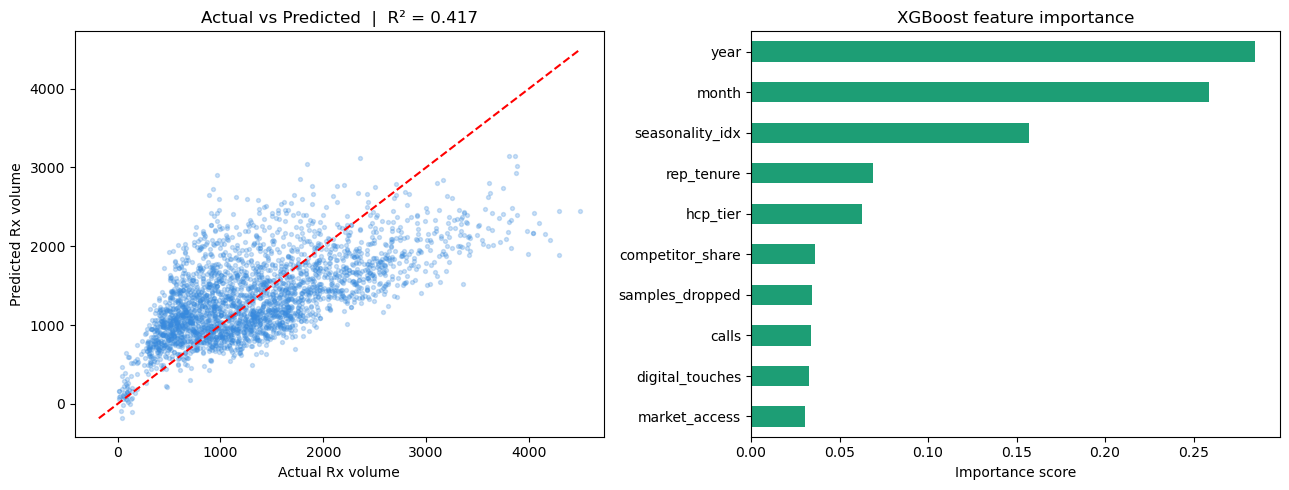

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_test, preds, alpha=0.25, s=8, color="#378ADD")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].set_xlabel("Actual Rx volume")
axes[0].set_ylabel("Predicted Rx volume")
axes[0].set_title(f"Actual vs Predicted  |  R² = {r2:.3f}")

# Feature importance
feat_imp = pd.Series(xgb.feature_importances_,
                     index=FEATURE_COLS).sort_values()
feat_imp.plot(kind="barh", ax=axes[1], color="#1D9E75", edgecolor="none")
axes[1].set_title("XGBoost feature importance")
axes[1].set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("outputs/08_model_results.png", dpi=150)
plt.show()

In [14]:
import joblib
import os

os.makedirs("data", exist_ok=True)

# Save the trained model
joblib.dump(xgb, "data/xgb_sfe_model.pkl")
print("✅ Model saved to data/xgb_sfe_model.pkl")

# Verify it saved correctly
import os
size = os.path.getsize("data/xgb_sfe_model.pkl")
print(f"   File size: {size/1024:.1f} KB")

✅ Model saved to data/xgb_sfe_model.pkl
   File size: 1043.7 KB
